<a href="https://colab.research.google.com/github/sanghyeok03/Ai-Project/blob/main/Autoencoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt-get -qq install fonts-nanum

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

# 설치된 나눔글꼴 경로로 직접 폰트 객체 생성
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fontprop = fm.FontProperties(fname=font_path)

# matplotlib에 등록
plt.rcParams["font.family"] = fontprop.get_name()

# 음수 기호 안 깨지게 설정
mpl.rcParams["axes.unicode_minus"] = False


In [1]:
from google.colab import files
uploaded = files.upload()

Saving cc_info.csv to cc_info.csv


Epoch 1/50, Loss: 0.9265
Epoch 2/50, Loss: 0.8790
Epoch 3/50, Loss: 0.8034
Epoch 4/50, Loss: 0.6983
Epoch 5/50, Loss: 0.6148
Epoch 6/50, Loss: 0.4940
Epoch 7/50, Loss: 0.4090
Epoch 8/50, Loss: 0.3197
Epoch 9/50, Loss: 0.2471
Epoch 10/50, Loss: 0.1762
Epoch 11/50, Loss: 0.1322
Epoch 12/50, Loss: 0.1025
Epoch 13/50, Loss: 0.0933
Epoch 14/50, Loss: 0.0746
Epoch 15/50, Loss: 0.0552
Epoch 16/50, Loss: 0.0432
Epoch 17/50, Loss: 0.0274
Epoch 18/50, Loss: 0.0198
Epoch 19/50, Loss: 0.0145
Epoch 20/50, Loss: 0.0108
Epoch 21/50, Loss: 0.0098
Epoch 22/50, Loss: 0.0093
Epoch 23/50, Loss: 0.0089
Epoch 24/50, Loss: 0.0075
Epoch 25/50, Loss: 0.0066
Epoch 26/50, Loss: 0.0063
Epoch 27/50, Loss: 0.0060
Epoch 28/50, Loss: 0.0060
Epoch 29/50, Loss: 0.0052
Epoch 30/50, Loss: 0.0049
Epoch 31/50, Loss: 0.0048
Epoch 32/50, Loss: 0.0045
Epoch 33/50, Loss: 0.0043
Epoch 34/50, Loss: 0.0043
Epoch 35/50, Loss: 0.0039
Epoch 36/50, Loss: 0.0039
Epoch 37/50, Loss: 0.0037
Epoch 38/50, Loss: 0.0041
Epoch 39/50, Loss: 0.

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


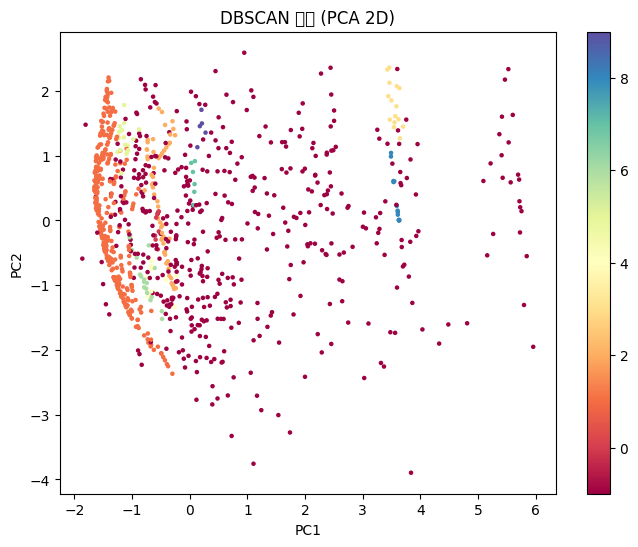

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

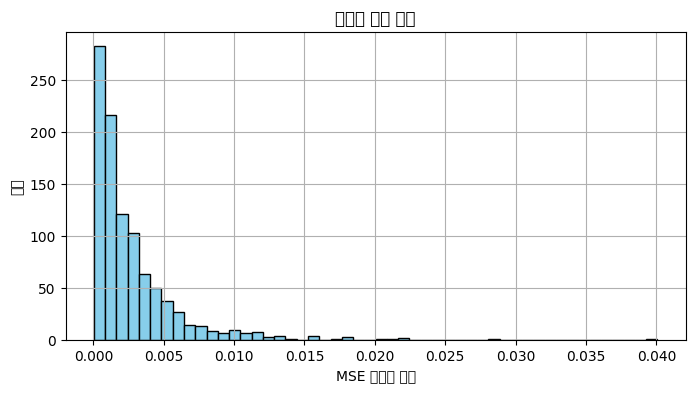

이상치 탐지 임계값: 0.0128
재구성 오류 기준 이상치 탐지 수: 19


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48152 (\N{HANGUL SYLLABLE BAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52824 (\N{HANGUL SYLLABLE CI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loc

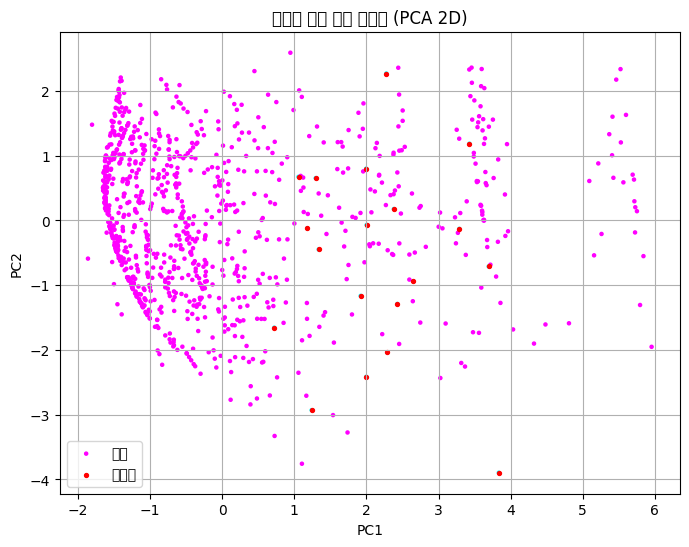

In [6]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv('cc_info.csv')

# 2. 사용 컬럼 선택
cols = ['city', 'credit_card', 'state', 'zipcode', 'credit_card_limit']
df_selected = df[cols].copy()

# 3. 범주형 변수 인코딩 (Label Encoding)
label_encoders = {}
for col in ['city', 'credit_card', 'state']:
    le = LabelEncoder()
    df_selected[col] = le.fit_transform(df_selected[col])
    label_encoders[col] = le

# 4. 정규화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_selected)

# 5. 학습 데이터 준비
X_train, X_val = train_test_split(X_scaled, test_size=0.2, random_state=42)
X_train_tensor = torch.FloatTensor(X_train)
X_val_tensor = torch.FloatTensor(X_val)
train_loader = torch.utils.data.DataLoader(X_train_tensor, batch_size=128, shuffle=True)

# 6. 오토인코더 정의
class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim=10):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, encoding_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

input_dim = X_scaled.shape[1]
model = Autoencoder(input_dim=input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 7. 모델 학습
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        outputs = model(batch)
        loss = criterion(outputs, batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {train_loss / len(train_loader):.4f}")

# 8. 인코딩된 데이터 추출
model.eval()
with torch.no_grad():
    encoded_data = model.encoder(torch.FloatTensor(X_scaled)).numpy()

# 9. DBSCAN 클러스터링
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(encoded_data)
outliers_dbscan = df[labels == -1]
print(f"DBSCAN 이상치 탐지 수: {len(outliers_dbscan)}")

# 10. PCA 시각화
reduced = PCA(n_components=2).fit_transform(encoded_data)
plt.figure(figsize=(8, 6))
plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap='Spectral', s=5)
plt.title("DBSCAN 결과 (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar()
plt.show()

# 11. 재구성 오류 계산
with torch.no_grad():
    X_tensor = torch.FloatTensor(X_scaled)
    reconstructed = model(X_tensor)
    reconstruction_error = torch.mean((X_tensor - reconstructed) ** 2, dim=1).numpy()

# 12. 재구성 오류 시각화
plt.figure(figsize=(8, 4))
plt.hist(reconstruction_error, bins=50, color='skyblue', edgecolor='black')
plt.title("재구성 오류 분포")
plt.xlabel("MSE 재구성 오류")
plt.ylabel("빈도")
plt.grid(True)
plt.show()

# 13. 이상치 기준 설정
threshold = np.mean(reconstruction_error) + 3 * np.std(reconstruction_error)
print(f"이상치 탐지 임계값: {threshold:.4f}")

anomaly_mask = reconstruction_error > threshold
reconstruction_outliers = df[anomaly_mask]
print(f"재구성 오류 기준 이상치 탐지 수: {len(reconstruction_outliers)}")

# 14. 이상치 시각화
plt.figure(figsize=(8, 6))
plt.scatter(reduced[:, 0], reduced[:, 1], c=~anomaly_mask, cmap='cool', s=5, label='정상')
plt.scatter(reduced[anomaly_mask, 0], reduced[anomaly_mask, 1], color='red', s=8, label='이상치')
plt.title("재구성 오류 기반 이상치 (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52280 (\N{HANGUL SYLLABLE CAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


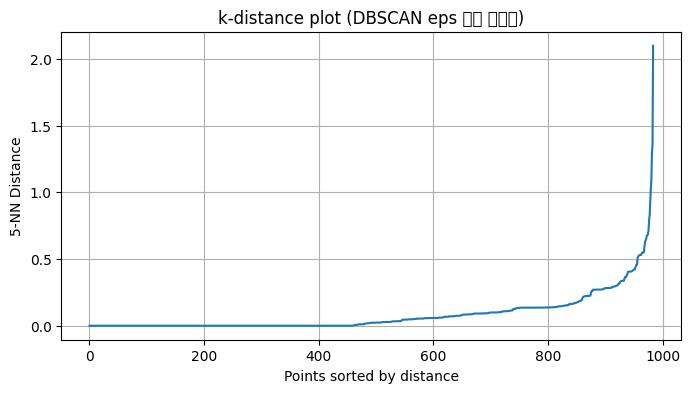

eps=0.3, min_samples=3 => 이상치 개수: 23 / 전체: 984
eps=0.3, min_samples=5 => 이상치 개수: 50 / 전체: 984
eps=0.3, min_samples=7 => 이상치 개수: 62 / 전체: 984
eps=0.5, min_samples=3 => 이상치 개수: 9 / 전체: 984
eps=0.5, min_samples=5 => 이상치 개수: 16 / 전체: 984
eps=0.5, min_samples=7 => 이상치 개수: 22 / 전체: 984
eps=0.7, min_samples=3 => 이상치 개수: 3 / 전체: 984
eps=0.7, min_samples=5 => 이상치 개수: 5 / 전체: 984
eps=0.7, min_samples=7 => 이상치 개수: 5 / 전체: 984
eps=1.0, min_samples=3 => 이상치 개수: 1 / 전체: 984
eps=1.0, min_samples=5 => 이상치 개수: 2 / 전체: 984
eps=1.0, min_samples=7 => 이상치 개수: 2 / 전체: 984
eps=1.3, min_samples=3 => 이상치 개수: 1 / 전체: 984
eps=1.3, min_samples=5 => 이상치 개수: 1 / 전체: 984
eps=1.3, min_samples=7 => 이상치 개수: 1 / 전체: 984


In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv('cc_info.csv')

# 2. 숫자형 컬럼만 선택 (여기선 임의로 수치형 컬럼 리스트 지정 가능)
numeric_cols = ['zipcode', 'credit_card_limit', 'transaction_amount', 'longitude', 'latitude']

# 열이 존재하는지 확인
missing_cols = [col for col in numeric_cols if col not in df.columns]
if missing_cols:
    print(f"Warning: The following columns were not found in the DataFrame: {missing_cols}")
    # Filter numeric_cols to only include those present in the DataFrame
    numeric_cols = [col for col in numeric_cols if col in df.columns]
    if not numeric_cols:
        raise ValueError("No valid numeric columns found in the DataFrame.")

X = df[numeric_cols].values

# 3. 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. k-distance plot 그리기 (eps 값 선정 도움)
n_neighbors_value = 5
if X_scaled.shape[0] < n_neighbors_value:
    print(f"Warning: Not enough samples ({X_scaled.shape[0]}) for NearestNeighbors with n_neighbors={n_neighbors_value}. Skipping k-distance plot.")
else:
    neigh = NearestNeighbors(n_neighbors=n_neighbors_value)
    nbrs = neigh.fit(X_scaled)
    distances, indices = nbrs.kneighbors(X_scaled)
    if distances.shape[1] > n_neighbors_value - 1:
        distances = np.sort(distances[:, n_neighbors_value - 1])  # 5번째 이웃 거리 (0-indexed)
        plt.figure(figsize=(8,4))
        plt.plot(distances)
        plt.xlabel('Points sorted by distance')
        plt.ylabel(f'{n_neighbors_value}-NN Distance')
        plt.title('k-distance plot (DBSCAN eps 선정 참고용)')
        plt.grid(True)
        plt.show()
    else:
        print(f"Warning: Cannot plot k-distance for {n_neighbors_value} neighbors with current data shape.")


# 5. 다양한 eps, min_samples 조합으로 DBSCAN 수행 및 이상치 수 출력
eps_values = [0.3, 0.5, 0.7, 1.0, 1.3]
min_samples_values = [3, 5, 7]

for eps in eps_values:
    for min_samples in min_samples_values:
        if min_samples > X_scaled.shape[0]:
             print(f"Skipping eps={eps}, min_samples={min_samples}: min_samples exceeds the number of samples.")
             continue

        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        n_outliers = (labels == -1).sum()
        print(f"eps={eps}, min_samples={min_samples} => 이상치 개수: {n_outliers} / 전체: {len(labels)}")